# Coloring the Euclidean Grid $[n]^2$

This notebook implements a simple, exact coloring solver for the Euclidean grid $[n]^2$.

In [72]:
# Imports & small utilities
from itertools import product
from functools import lru_cache
from typing import List, Tuple, Optional, Callable, Dict
import time

Point = Tuple[int,int]  # euclidean pair (x,y) represented as ints

## The Euclidean grid


A factory of Euclidean grids

In [73]:
def euclidean_grid(n):
    """Generate all points in an n x n euclidean grid, from 1 to n"""
    return [(x+1, y+1) for x, y in product(range(n), repeat=2)]

# Example for n=3
print(euclidean_grid(3))

[(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3), (3, 1), (3, 2), (3, 3)]


## Collinearity in the Euclidean Plane

We use the integer determinant test to check if three points $(x_1, y_1), (x_2, y_2), (x_3, y_3)$ are collinear.

In [74]:
def are_collinear(p1: Point, p2: Point, p3: Point) -> bool:
    """
    Returns True if points p1, p2, p3 are collinear in the Euclidean plane.
    Each point is a tuple (x, y) of integers.
    Uses the determinant test:
    | x1 y1 1 |
    | x2 y2 1 | = 0
    | x3 y3 1 |
    Python integers can handle arbitrary size, so no numerical issues arise.
    """
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    det = x1 * (y2 - y3) - y1 * (x2 - x3) + (x2 * y3 - x3 * y2)
    return det == 0

# Example usage:
print(are_collinear((0,0), (1,1), (2,2)))  # True
print(are_collinear((0,0), (1,2), (2,1)))  # False

True
False


## Coloring Solver: MRV and Forward Checking

We now implement a backtracking coloring solver for the Euclidean grid using the Minimum Remaining Values (MRV) heuristic and forward checking, closely following the approach in clean_proyectivo.

In [75]:
from itertools import combinations

def solve_coloring(
    points: List[Point],
    num_colors: int,
    partial_write_path: Optional[str] = None,
    progress_callback: Optional[Callable[[int, int, int], None]] = None,
    timeout: Optional[float] = None
) -> Optional[List[Optional[int]]]:
    """
    Attempt to color `points` with `num_colors` so that no color class contains 3 collinear points.
    Parameters:
      points: list of points (z != 0)
      num_colors: number of colors
      gf: field instance
      H: optional dict mapping point-index -> preassigned color
      partial_write_path: optional path to append best partial assignments when new max depth reached
      progress_callback: optional callable(depth, nodes_explored, max_depth) to report progress
      timeout: optional seconds after which the solver stops and returns None
    Returns: assignment list of length N or None on failure/timeout.
    """
    import sys
    N = len(points)
    assign = [None] * N
    domains = [set(range(num_colors)) for _ in range(N)]
    color_class = {c: [] for c in range(num_colors)}
    change_stack = []
    nodes_explored = 0
    max_depth_reached = 0
    start_time = time.time()
    # Default progress callback: print when max depth increases
    def default_progress_callback(depth, nodes_explored, max_depth):
        print(f"[Progress] Depth: {depth}, Nodes: {nodes_explored}, Max depth: {max_depth}")
        sys.stdout.flush()
    if progress_callback is None:
        progress_callback = default_progress_callback
    def push(entry):
        change_stack.append(entry)
    def undo(count):
        for _ in range(count):
            typ, data = change_stack.pop()
            if typ == 'assign':
                i, old = data; assign[i] = old
            elif typ == 'domain_remove':
                i, c = data; domains[i].add(c)
            elif typ == 'color_remove':
                i, c = data; color_class[c].remove(i)
    def update_progress(depth):
        nonlocal nodes_explored, max_depth_reached
        nodes_explored += 1
        wrote = False
        # first = assign[0] if N > 0 else None
        # second = assign[7] if N > 7 else None
        # third = assign[8] if N > 8 else None
        # # Track previous values to detect changes
        # if not hasattr(update_progress, "prev_first"):
        #     update_progress.prev_first = None
        #     update_progress.prev_second = None
        #     update_progress.prev_third = None
        # changed = (
        #     first != update_progress.prev_first or
        #     second != update_progress.prev_second or
        #     third != update_progress.prev_third
        # )
        # if changed:
        #     print(f"[Progress] First three assignments changed: {first}, {second}, {third} at depth {depth}")
        #     update_progress.prev_first = first
        #     update_progress.prev_second = second
        #     update_progress.prev_third = third
        if depth > max_depth_reached:
            max_depth_reached = depth
            if partial_write_path is not None:
                with open(partial_write_path, 'a') as f:
                    f.write(','.join(str(assign[i]) if assign[i] is not None else '-' for i in range(N)) + '\n')
                wrote = True
            if progress_callback is not None:
                progress_callback(depth, nodes_explored, max_depth_reached)
        return wrote
    def select_var():
        # MRV: choose unassigned variable with smallest domain
        best = None; best_size = 10**9
        for i in range(N):
            if assign[i] is None:
                s = len(domains[i])
                if s < best_size:
                    best_size = s; best = i
        return best
    def forward_check(i, color):
        # record assignment
        old = assign[i]
        assign[i] = color; push(('assign',(i,old)))
        color_class[color].append(i); push(('color_remove',(i,color)))
        # for each existing pair in color class, check third points
        for q in color_class[color]:
            if q == i: continue
            for r in range(N):
                if r == i or r == q: continue
                if assign[r] == color:
                    if are_collinear(points[i], points[q], points[r]):
                        return False
                elif assign[r] is None:
                    if color in domains[r]:
                        if are_collinear(points[i], points[q], points[r]):
                            domains[r].remove(color); push(('domain_remove',(r,color)))
                            if not domains[r]:
                                return False
        return True
    def backtrack(depth=0):
        if timeout is not None and (time.time() - start_time) > timeout:
            return False
        update_progress(depth)
        if all(a is not None for a in assign):
            return True
        v = select_var()
        if v is None: return True
        domain_snapshot = sorted(domains[v])
        for c in domain_snapshot:
            checkpoint = len(change_stack)
            ok = forward_check(v, c)
            if ok:
                if backtrack(depth+1):
                    return True
            undo(len(change_stack) - checkpoint)
        return False
    success = backtrack(0)
    if success: return assign
    return None


## Example: Coloring $[n]^2$ and Saving the Result

We generate the grid $[n]^2$, run the coloring solver, and save the output as `(x,y): j` per line.

In [76]:
n = 3  # grid size
k = 2  # number of colors
points = euclidean_grid(n)

result = solve_coloring(points, k)
if result is not None:
    print("Success! Coloring:")
    print(result)
    # Save result to file
    with open(f'grid_{n}x{n}_coloring.txt', 'w') as f:
        for idx, color in enumerate(result):
            x, y = points[idx]
            f.write(f"({x},{y}): {color+1}\n")
    print(f"Result saved to grid_{n}x{n}_coloring.txt")
else:
    print("No coloring found (timeout or impossible)")

[Progress] Depth: 1, Nodes: 2, Max depth: 1
[Progress] Depth: 2, Nodes: 3, Max depth: 2
[Progress] Depth: 3, Nodes: 4, Max depth: 3
[Progress] Depth: 4, Nodes: 5, Max depth: 4
[Progress] Depth: 5, Nodes: 6, Max depth: 5
[Progress] Depth: 6, Nodes: 7, Max depth: 6
[Progress] Depth: 7, Nodes: 11, Max depth: 7
[Progress] Depth: 8, Nodes: 12, Max depth: 8
[Progress] Depth: 9, Nodes: 13, Max depth: 9
Success! Coloring:
[0, 0, 1, 1, 0, 0, 0, 1, 1]
Result saved to grid_3x3_coloring.txt


## Precise Values: Minimal Colors for $[n]^2$


### Exact values for $n=1,\ldots,7$ using backtrack
For each $n=1,2,\ldots,7$, we find the minimal $k$ such that $[n]^2$ can be colored with no three collinear points in any color class, using binary search.

In [77]:
# Find minimal k for each n=1...7 such that [n]^2 can be colored
# with no three collinear points in any color class.

min_k_for_n = []
results = {}  # Store the coloring result for the minimal k for each n

for n in range(1, 8):
    print(f"n={n}")
    points = euclidean_grid(n)
    low, high = 1, n
    answer = n
    best_res = None
    while low <= high:
        mid = (low + high) // 2
        print(f"  Trying k={mid}...", end=" ")
        res = solve_coloring(points, mid)
        if res is not None:
            print(n,mid,"OK")
            answer = mid
            best_res = res  # Save the result for the current minimal k
            high = mid - 1
        else:
            print(n,mid,"FAIL")
            low = mid + 1
    min_k_for_n.append(answer)
    results[n] = best_res  # Save the result for the minimal k
    print(f"  Minimal k for n={n}: {answer}\n")

print("Results (n, min_k):")
for n, k in enumerate(min_k_for_n, 1):
    print(f"n={n}: k={k}")

n=1
  Trying k=1... [Progress] Depth: 1, Nodes: 2, Max depth: 1
1 1 OK
  Minimal k for n=1: 1

n=2
  Trying k=1... [Progress] Depth: 1, Nodes: 2, Max depth: 1
[Progress] Depth: 2, Nodes: 3, Max depth: 2
[Progress] Depth: 3, Nodes: 4, Max depth: 3
[Progress] Depth: 4, Nodes: 5, Max depth: 4
2 1 OK
  Minimal k for n=2: 1

n=3
  Trying k=2... [Progress] Depth: 1, Nodes: 2, Max depth: 1
[Progress] Depth: 2, Nodes: 3, Max depth: 2
[Progress] Depth: 3, Nodes: 4, Max depth: 3
[Progress] Depth: 4, Nodes: 5, Max depth: 4
[Progress] Depth: 5, Nodes: 6, Max depth: 5
[Progress] Depth: 6, Nodes: 7, Max depth: 6
[Progress] Depth: 7, Nodes: 11, Max depth: 7
[Progress] Depth: 8, Nodes: 12, Max depth: 8
[Progress] Depth: 9, Nodes: 13, Max depth: 9
3 2 OK
  Trying k=1... [Progress] Depth: 1, Nodes: 2, Max depth: 1
3 1 FAIL
  Minimal k for n=3: 2

n=4
  Trying k=2... [Progress] Depth: 1, Nodes: 2, Max depth: 1
[Progress] Depth: 2, Nodes: 3, Max depth: 2
[Progress] Depth: 3, Nodes: 4, Max depth: 3
[Progre

### Case $n=8$ times out using backtrack

We set a default timeout of 3 minutes. The max depth suggests this approach is unfeasible.

In [78]:
n=8
k=4
points = euclidean_grid(n)
res = solve_coloring(points, k, timeout=180)

if res is not None:
    # Add to results dictionary
    results[n] = res
else:
    print(f"No coloring found for n={n} with k={k}")

[Progress] Depth: 1, Nodes: 2, Max depth: 1
[Progress] Depth: 2, Nodes: 3, Max depth: 2
[Progress] Depth: 3, Nodes: 4, Max depth: 3
[Progress] Depth: 4, Nodes: 5, Max depth: 4
[Progress] Depth: 5, Nodes: 6, Max depth: 5
[Progress] Depth: 6, Nodes: 7, Max depth: 6
[Progress] Depth: 7, Nodes: 8, Max depth: 7
[Progress] Depth: 8, Nodes: 9, Max depth: 8
[Progress] Depth: 9, Nodes: 10, Max depth: 9
[Progress] Depth: 10, Nodes: 11, Max depth: 10
[Progress] Depth: 11, Nodes: 12, Max depth: 11
[Progress] Depth: 12, Nodes: 13, Max depth: 12
[Progress] Depth: 13, Nodes: 14, Max depth: 13
[Progress] Depth: 14, Nodes: 15, Max depth: 14
[Progress] Depth: 15, Nodes: 16, Max depth: 15
[Progress] Depth: 16, Nodes: 17, Max depth: 16
[Progress] Depth: 17, Nodes: 18, Max depth: 17
[Progress] Depth: 18, Nodes: 19, Max depth: 18
[Progress] Depth: 19, Nodes: 20, Max depth: 19
[Progress] Depth: 20, Nodes: 21, Max depth: 20
[Progress] Depth: 21, Nodes: 22, Max depth: 21
[Progress] Depth: 22, Nodes: 23, Max de

### Case $n=9$, upper bound $k=6$ using backtrack

In [ ]:
# We prove an upper bound for the arc chromatic number of the 9x9 grid.
n=9
k=6
points = euclidean_grid(n)
res = solve_coloring(points, k)

if res is not None:
    print("Coloring found for n=9 with k=6")
else:
    print(f"No coloring found for n={n} with k={k}")

[Progress] Depth: 1, Nodes: 2, Max depth: 1
[Progress] Depth: 2, Nodes: 3, Max depth: 2
[Progress] Depth: 3, Nodes: 4, Max depth: 3
[Progress] Depth: 4, Nodes: 5, Max depth: 4
[Progress] Depth: 5, Nodes: 6, Max depth: 5
[Progress] Depth: 6, Nodes: 7, Max depth: 6
[Progress] Depth: 7, Nodes: 8, Max depth: 7
[Progress] Depth: 8, Nodes: 9, Max depth: 8
[Progress] Depth: 9, Nodes: 10, Max depth: 9
[Progress] Depth: 10, Nodes: 11, Max depth: 10
[Progress] Depth: 11, Nodes: 12, Max depth: 11
[Progress] Depth: 12, Nodes: 13, Max depth: 12
[Progress] Depth: 13, Nodes: 14, Max depth: 13
[Progress] Depth: 14, Nodes: 15, Max depth: 14
[Progress] Depth: 15, Nodes: 16, Max depth: 15
[Progress] Depth: 16, Nodes: 17, Max depth: 16
[Progress] Depth: 17, Nodes: 18, Max depth: 17
[Progress] Depth: 18, Nodes: 19, Max depth: 18
[Progress] Depth: 19, Nodes: 20, Max depth: 19
[Progress] Depth: 20, Nodes: 21, Max depth: 20
[Progress] Depth: 21, Nodes: 22, Max depth: 21
[Progress] Depth: 22, Nodes: 23, Max de

In [80]:
# The backtrack approach for k=5 fails to find a coloring for n=9 within reasonable time.
# The depth report suggests the approach is unfeasible.
n=9
k=5
points = euclidean_grid(n)
res = solve_coloring(points, k, timeout=180)

if res is not None:
    print("Coloring found for n=9 with k=5")
else:
    print(f"No coloring found for n={n} with k={k}")

[Progress] Depth: 1, Nodes: 2, Max depth: 1
[Progress] Depth: 2, Nodes: 3, Max depth: 2
[Progress] Depth: 3, Nodes: 4, Max depth: 3
[Progress] Depth: 4, Nodes: 5, Max depth: 4
[Progress] Depth: 5, Nodes: 6, Max depth: 5
[Progress] Depth: 6, Nodes: 7, Max depth: 6
[Progress] Depth: 7, Nodes: 8, Max depth: 7
[Progress] Depth: 8, Nodes: 9, Max depth: 8
[Progress] Depth: 9, Nodes: 10, Max depth: 9
[Progress] Depth: 10, Nodes: 11, Max depth: 10
[Progress] Depth: 11, Nodes: 12, Max depth: 11
[Progress] Depth: 12, Nodes: 13, Max depth: 12
[Progress] Depth: 13, Nodes: 14, Max depth: 13
[Progress] Depth: 14, Nodes: 15, Max depth: 14
[Progress] Depth: 15, Nodes: 16, Max depth: 15
[Progress] Depth: 16, Nodes: 17, Max depth: 16
[Progress] Depth: 17, Nodes: 18, Max depth: 17
[Progress] Depth: 18, Nodes: 19, Max depth: 18
[Progress] Depth: 19, Nodes: 20, Max depth: 19
[Progress] Depth: 20, Nodes: 21, Max depth: 20
[Progress] Depth: 21, Nodes: 22, Max depth: 21
[Progress] Depth: 22, Nodes: 23, Max de

## The value for $n=8$ first finding arcs

### Find arcs via recursion

An arc-proper $4$-coloring of the $n=8$ grid requires that each color class has 16 elements, and then is an arc (general position set) with two points in each row.

We recursively construct all sets of $2k$ points in a $k \times 8$ grid, using exactly 2 points per row, such that no three points are collinear.

- The base case for $1 \times 8$ is all pairs of columns.
- For $(k+1) \times 8$, we extend each valid $k \times 8$ set by adding 2 points in the new row, checking that no collinearities are created.

In [82]:
from itertools import combinations

def extend_general_position_sets(prev_sets, new_row, n_cols):
    """
    Given previous sets (each with 2 points per row),
    extend by adding 2 points in the new row, avoiding collinearities.
    prev_sets: list of sets of points
    new_row: int (row index to add)
    Returns: list of new sets
    """
    new_sets = []
    col_pairs = list(combinations(range(n_cols), 2))
    for s in prev_sets:
        for c1, c2 in col_pairs:
            candidate = s | {(new_row, c1), (new_row, c2)}
            # Check all triples for collinearity
            valid = True
            pts = list(candidate)
            for i in range(len(pts)):
                for j in range(i+1, len(pts)):
                    for k in range(j+1, len(pts)):
                        if are_collinear(pts[i], pts[j], pts[k]):
                            valid = False
                            break
                    if not valid: break
                if not valid: break
            if valid:
                new_sets.append(candidate)
    return new_sets

def all_general_position_sets_k_rows(k, n_cols):
    """
    Recursively build all general position sets with 2 points per row in k x n_cols grid.
    Returns: list of sets of points
    """
    # Base case: 1x8, all pairs of columns
    base_sets = [{(0, c1), (0, c2)} for c1, c2 in combinations(range(n_cols), 2)]
    sets = base_sets
    for row in range(1, k):
        sets = extend_general_position_sets(sets, row, n_cols)
        print(f"Row {row+1}: {len(sets)} sets")
    return sets

# Example: Find all general position sets for 3x8 grid (may be slow)
sets_8x8 = all_general_position_sets_k_rows(8, 8)
print(f"Number of sets for 3x8: {len(sets_8x8)}")

Row 2: 784 sets
Row 3: 12400 sets
Row 4: 93171 sets
Row 5: 217169 sets
Row 6: 204606 sets
Row 7: 21423 sets
Row 8: 380 sets
Number of sets for 3x8: 380


In [84]:
# Store each set as a line in a file, each line is a list of 16 (row, col) pairs
with open("./results_euclidean/gp_sets_8x8.txt", "w") as f:
    for s in sets_8x8:
        # Sort points for consistency
        line = " ".join(f"({r},{c})" for r, c in sorted(s))
        f.write(line + "\n")
print("Saved all 8x8 general position sets to ./results_euclidean/gp_sets_8x8.txt")

Saved all 8x8 general position sets to ./results_euclidean/gp_sets_8x8.txt


### Visualize some of the maximal arcs found in the 8x8 grid

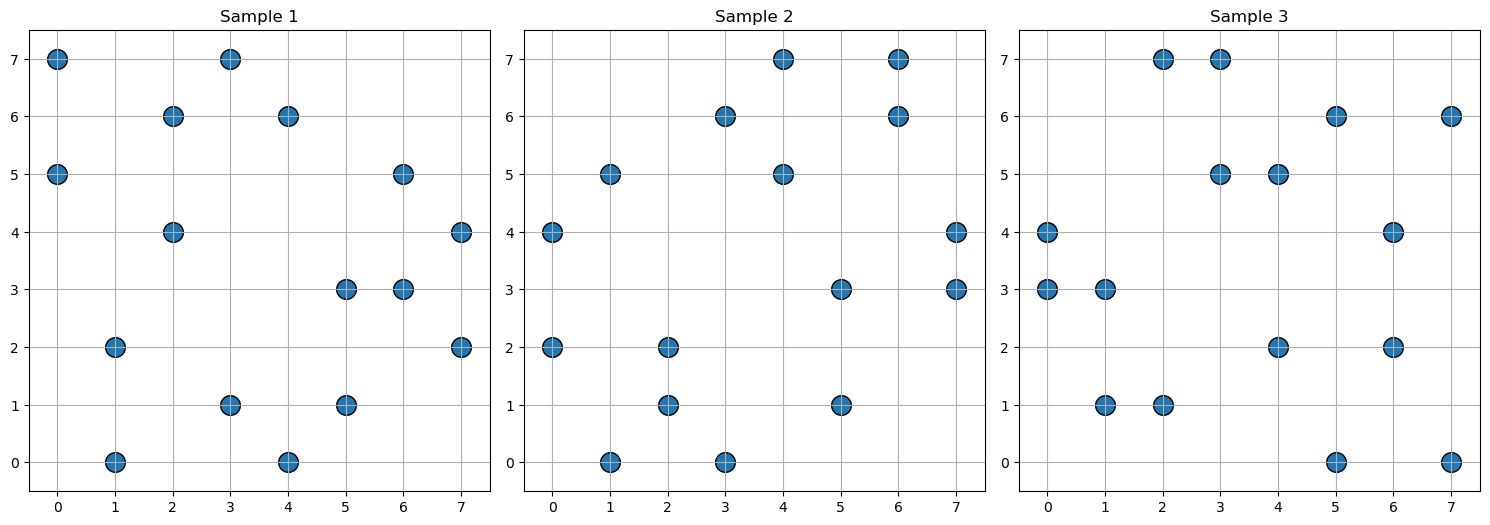

In [87]:
import matplotlib.pyplot as plt
import random

# Visualize three random general position sets from sets_8x8
sample_sets = random.sample(sets_8x8, 3)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (s, ax) in enumerate(zip(sample_sets, axes)):
    xs = [c for r, c in s]
    ys = [r for r, c in s]
    ax.scatter(xs, ys, s=200, c='tab:blue', edgecolors='k')
    ax.set_title(f"Sample {idx+1}")
    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(-0.5, 7.5)
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.set_aspect('equal')
    ax.grid(True)
plt.tight_layout()
plt.show()


### Finding Pairwise Disjoint Sets

Below we implement a backtracking algorithm to find one collection of $b$ pairwise disjoint sets from a given list of sets. The function returns the actual sets if a solution exists, or `None` otherwise. Set operations are used for fast disjointness checks.


In [88]:
def find_pairwise_disjoint_sets(sets_list, b):
    """
    Finds one collection of b pairwise disjoint sets from sets_list.
    Args:
        sets_list: list of sets (e.g., list of set of points)
        b: number of pairwise disjoint sets to find
    Returns:
        List of b disjoint sets if found, else None
    """
    n = len(sets_list)
    result = []
    used = set()

    def backtrack(current, start):
        if len(current) == b:
            return list(current)
        if n - start + len(current) < b:
            return None
        for i in range(start, n):
            s = sets_list[i]
            if all(s.isdisjoint(t) for t in current):
                current.append(s)
                found = backtrack(current, i+1)
                if found is not None:
                    return found
                current.pop()
        return None

    return backtrack([], 0)

In [89]:
# We are ready to test whether there are 4 disjoint
# maximal general position sets in the 8x8 grid.

sets = sets_8x8  # Using previously computed sets for 8x8 grid

sets_as_sets = [set(map(tuple, s)) for s in sets]

b4_result = find_pairwise_disjoint_sets(sets_as_sets, 4)

print(f"b=4: Found? {b4_result is not None}")
if b4_result:
    for idx, s in enumerate(b4_result):
        # Print each set, but add 1 to row/col for 1-based indexing
        print(f"Set {idx+1}: {[ (r+1, c+1) for r, c in s ]}")

b=4: Found? True
Set 1: [(7, 3), (1, 5), (8, 2), (3, 3), (1, 1), (5, 4), (4, 8), (6, 2), (2, 5), (6, 8), (3, 4), (5, 6), (4, 7), (7, 1), (2, 7), (8, 6)]
Set 2: [(1, 2), (8, 5), (2, 3), (3, 2), (3, 8), (5, 7), (7, 7), (7, 5), (8, 1), (2, 1), (4, 4), (1, 6), (6, 4), (5, 8), (4, 6), (6, 3)]
Set 3: [(5, 1), (6, 6), (8, 8), (4, 5), (2, 6), (7, 2), (6, 5), (3, 1), (1, 7), (8, 4), (1, 3), (2, 8), (3, 7), (4, 3), (7, 4), (5, 2)]
Set 4: [(5, 5), (1, 8), (3, 5), (7, 6), (4, 2), (2, 2), (1, 4), (5, 3), (4, 1), (7, 8), (8, 7), (6, 1), (6, 7), (8, 3), (3, 6), (2, 4)]


In [103]:
# Prepare results[8]

points = euclidean_grid(8)
results8=[]

for idx_pt, point in enumerate(points):
    for idx_part, part in enumerate(b4_result):
        if (point[0]-1,point[1]-1) in part:
            results8.append(idx_part)

# Show
results[8] = results8

In [ ]:
# x=[]
# y=[]
# colors=[]
# for idx, color_class in enumerate(b4_result):
#     for (r,c) in color_class:
#         x.append(r)
#         y.append(c)
#         colors.append(idx)


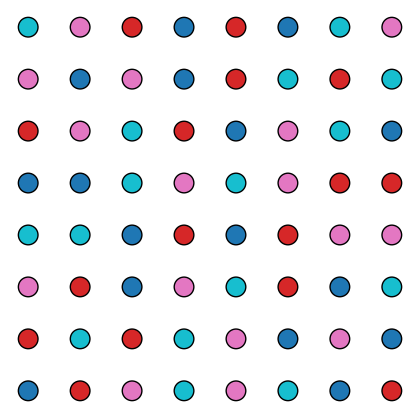

Saved PDF for n=8 to grid_8x8_coloring.pdf


In [ ]:
# n=8
# plt.figure(figsize=(4,4))
# plt.scatter(x, y, c=colors, cmap='tab10', s=200, edgecolors='k')
# plt.axis('off')
# plt.tight_layout(pad=0)
# pdf_filename = f'grid_{n}x{n}_coloring.pdf'
# plt.savefig(pdf_filename, bbox_inches='tight', pad_inches=0)
# plt.show()
# print(f"Saved PDF for n={n} to {pdf_filename}")

## Save and visualize resuls

Saved coloring for n=1 to ./results_euclidean/grid_1x1_coloring.txt
Saved classes for n=1 to ./results_euclidean/grid_1x1_classes.txt


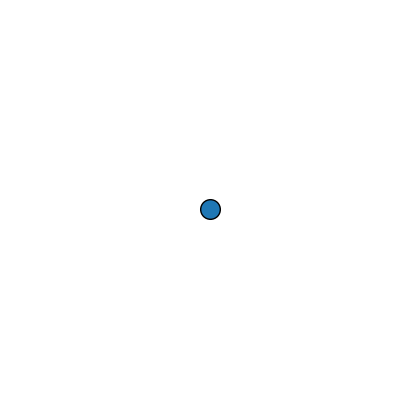

Saved PDF for n=1 to ./results_euclidean/grid_1x1_coloring.pdf
Saved coloring for n=2 to ./results_euclidean/grid_2x2_coloring.txt
Saved classes for n=2 to ./results_euclidean/grid_2x2_classes.txt


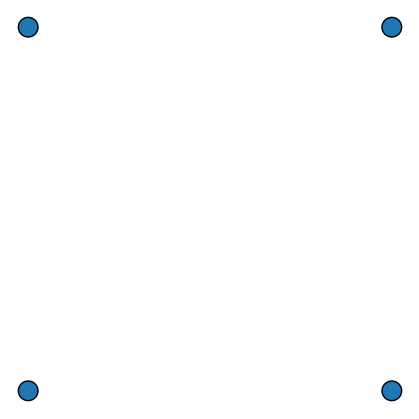

Saved PDF for n=2 to ./results_euclidean/grid_2x2_coloring.pdf
Saved coloring for n=3 to ./results_euclidean/grid_3x3_coloring.txt
Saved classes for n=3 to ./results_euclidean/grid_3x3_classes.txt


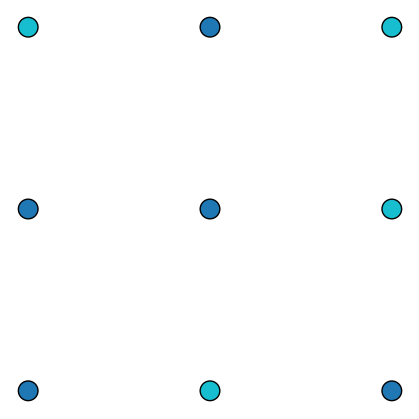

Saved PDF for n=3 to ./results_euclidean/grid_3x3_coloring.pdf
Saved coloring for n=4 to ./results_euclidean/grid_4x4_coloring.txt
Saved classes for n=4 to ./results_euclidean/grid_4x4_classes.txt


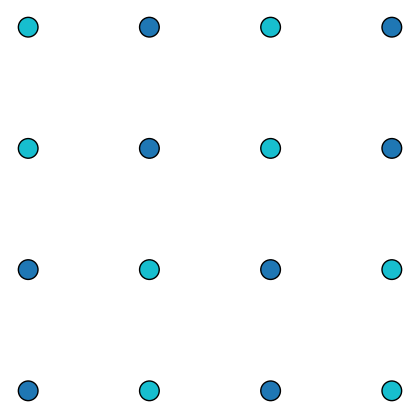

Saved PDF for n=4 to ./results_euclidean/grid_4x4_coloring.pdf
Saved coloring for n=5 to ./results_euclidean/grid_5x5_coloring.txt
Saved classes for n=5 to ./results_euclidean/grid_5x5_classes.txt


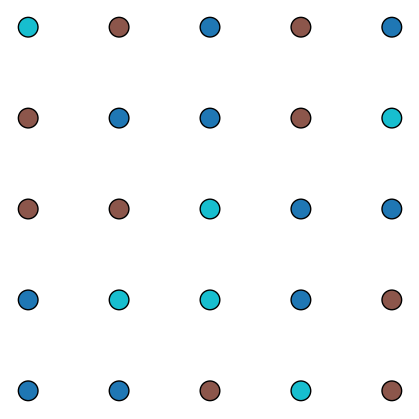

Saved PDF for n=5 to ./results_euclidean/grid_5x5_coloring.pdf
Saved coloring for n=6 to ./results_euclidean/grid_6x6_coloring.txt
Saved classes for n=6 to ./results_euclidean/grid_6x6_classes.txt


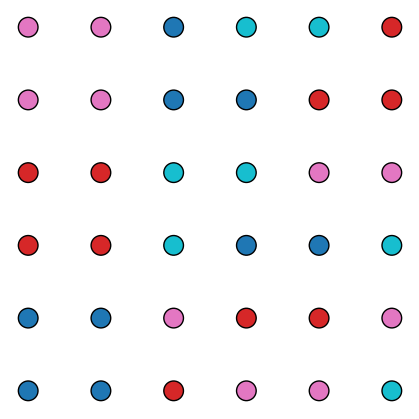

Saved PDF for n=6 to ./results_euclidean/grid_6x6_coloring.pdf
Saved coloring for n=7 to ./results_euclidean/grid_7x7_coloring.txt
Saved classes for n=7 to ./results_euclidean/grid_7x7_classes.txt


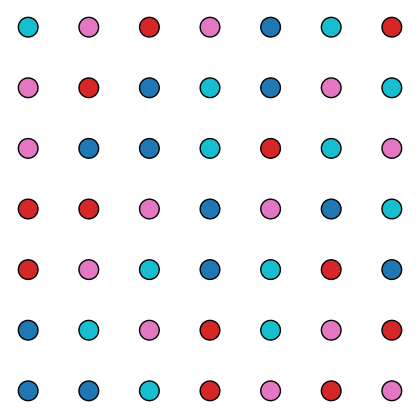

Saved PDF for n=7 to ./results_euclidean/grid_7x7_coloring.pdf
Saved coloring for n=8 to ./results_euclidean/grid_8x8_coloring.txt
Saved classes for n=8 to ./results_euclidean/grid_8x8_classes.txt


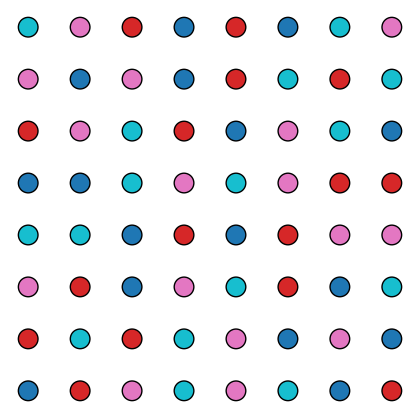

Saved PDF for n=8 to ./results_euclidean/grid_8x8_coloring.pdf


In [104]:
# Save and visualize each minimal coloring result for n=1..7
import matplotlib.pyplot as plt
import numpy as np

for n, coloring in results.items():
    if coloring is None:
        print(f"No coloring found for n={n}")
        continue
    points = [(x, y) for x in range(1, n+1) for y in range(1, n+1)]
    # Save to file
    filename_coloring = f'./results_euclidean/grid_{n}x{n}_coloring.txt'
    with open(filename_coloring, 'w') as f:
        for idx, color in enumerate(coloring):
            x, y = points[idx]
            f.write(f"({x},{y}): {color+1}\n")
    print(f"Saved coloring for n={n} to {filename_coloring}")
    # Save color classes: each line is "color: [list of points]"
    filename_classes = f'./results_euclidean/grid_{n}x{n}_classes.txt'
    color_classes = {}
    for idx, color in enumerate(coloring):
        pt = points[idx]
        color_classes.setdefault(color+1, []).append(pt)
    with open(filename_classes, 'w') as f:
        for color, pts in color_classes.items():
            f.write(f"{color}: {pts}\n")
    print(f"Saved classes for n={n} to {filename_classes}")
    # Visualize (simple: just points, no axes, no labels, no title)
    x = [pt[0] for pt in points]
    y = [pt[1] for pt in points]
    colors = np.array([c+1 for c in coloring])
    plt.figure(figsize=(4,4))
    plt.scatter(x, y, c=colors, cmap='tab10', s=200, edgecolors='k')
    plt.axis('off')
    plt.tight_layout(pad=0)
    pdf_filename = f'./results_euclidean/grid_{n}x{n}_coloring.pdf'
    plt.savefig(pdf_filename, bbox_inches='tight', pad_inches=0)
    plt.show()
    print(f"Saved PDF for n={n} to {pdf_filename}")

## Appendix: Double check for $n=6$, with the arc-first approach

We use the approach of first finding maximal arc to perform a double check that the arc chromatic number in this case is $4$ (and not $3$).

In [105]:
sets_6x6 = all_general_position_sets_k_rows(6, 6)
print(f"Number of sets for 6x6: {len(sets_6x6)}")

Row 2: 225 sets
Row 3: 1506 sets
Row 4: 3565 sets
Row 5: 1209 sets
Row 6: 50 sets
Number of sets for 6x6: 50


In [106]:
# Store each set as a line in a file, each line is a list of 12 (row, col) pairs
with open("./results_euclidean/gp_sets_6x6.txt", "w") as f:
    for s in sets_6x6:
        # Sort points for consistency
        line = " ".join(f"({r},{c})" for r, c in sorted(s))
        f.write(line + "\n")
print("Saved all 6x6 general position sets to gp_sets_6x6.txt")


Saved all 6x6 general position sets to gp_sets_6x6.txt


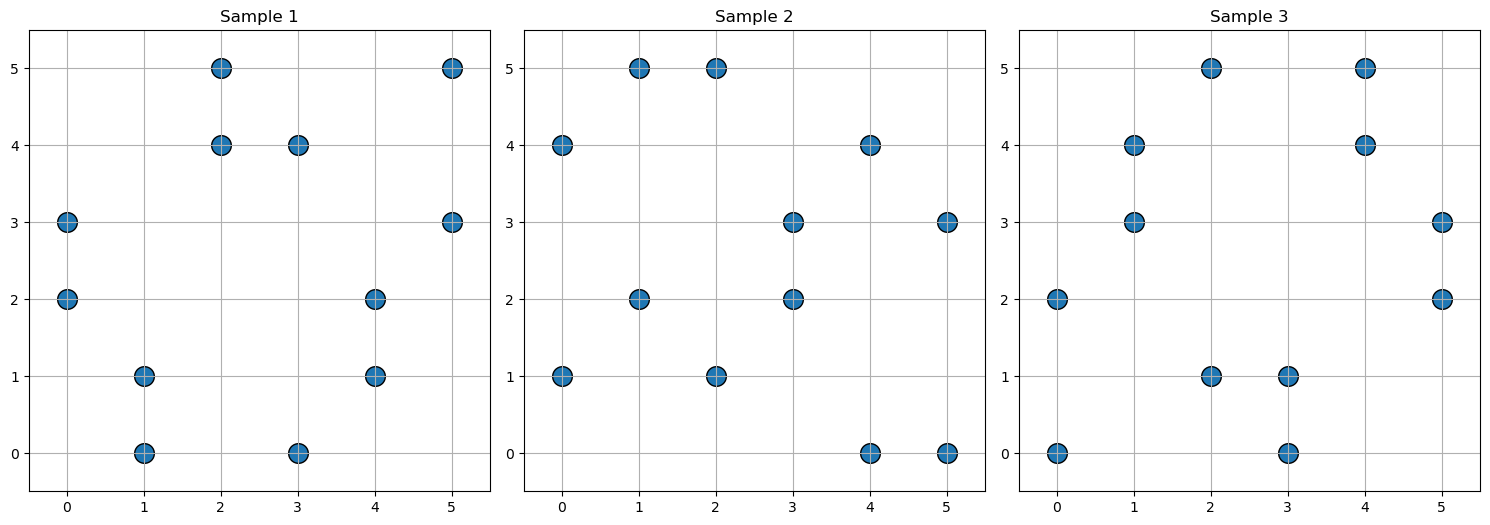

In [107]:
import matplotlib.pyplot as plt
import random

# Visualize three random general position sets from sets_6x6
if len(sets_6x6) >= 3:
    sample_sets = random.sample(sets_6x6, 3)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for idx, (s, ax) in enumerate(zip(sample_sets, axes)):
        xs = [c for r, c in s]
        ys = [r for r, c in s]
        ax.scatter(xs, ys, s=200, c='tab:blue', edgecolors='k')
        ax.set_title(f"Sample {idx+1}")
        ax.set_xlim(-0.5, 5.5)
        ax.set_ylim(-0.5, 5.5)
        ax.set_xticks(range(6))
        ax.set_yticks(range(6))
        ax.set_aspect('equal')
        ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough sets to sample from.")


## Finding b Pairwise Disjoint Sets


In [108]:
sets = sets_6x6  # Using previously computed sets for 6x6 grid

sets_as_sets = [set(map(tuple, s)) for s in sets]

b3_result = find_pairwise_disjoint_sets(sets_as_sets, 3)
print(f"b=3: Found? {b3_result is not None}")
if b3_result:
    for idx, s in enumerate(b3_result):
        print(f"Set {idx+1}: {s}")

b=3: Found? False


In [109]:
# Two disjoint maximal arcs do exist.
b2_result = find_pairwise_disjoint_sets(sets_as_sets, 2)
print(f"b=3: Found? {b2_result is not None}")
if b2_result:
    for idx, s in enumerate(b2_result):
        print(f"Set {idx+1}: {s}")

b=3: Found? True
Set 1: {(0, 1), (4, 4), (2, 4), (2, 1), (0, 0), (1, 5), (3, 0), (4, 5), (5, 3), (3, 2), (1, 3), (5, 2)}
Set 2: {(4, 0), (5, 5), (3, 4), (3, 1), (1, 1), (0, 3), (5, 4), (4, 2), (2, 3), (0, 2), (1, 0), (2, 5)}


In [110]:
x=[]
y=[]
colors=[]
for idx, color_class in enumerate(b2_result):
    for (r,c) in color_class:
        x.append(c)
        y.append(r)
        colors.append(idx)


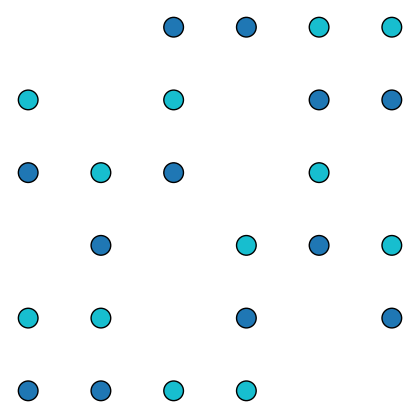

In [112]:
n=6
plt.figure(figsize=(4,4))
plt.scatter(x, y, c=colors, cmap='tab10', s=200, edgecolors='k')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()